In [60]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
from keras import layers
from keras.models import Sequential
from keras.losses import binary_crossentropy
from keras.datasets import fashion_mnist

We used fashion-mnist dataset in this notebook.

In [61]:
# load data
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28, 1)


The Fashion-MNIST dataset is loaded and normalized.

In [62]:
latent_dim = 16
input_shape = (28,28,1)

The latent dimension determines how much the image is compressed.

In [63]:
# encoder
encoder_inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32,3,activation="relu",strides=2,padding="same")(encoder_inputs)

x = layers.Conv2D(64,3,activation="relu",strides=2,padding="same")(x)

x = layers.Flatten()(x)

x = layers.Dense(128,activation="relu")(x)

z_mean = layers.Dense(latent_dim,name="z_mean")(x)

z_log_var = layers.Dense(latent_dim,name="z_log_var")(x)

First we built the encoder structure and in the last layer calculated the mean and logarithm of the variance of the output. The conv2 layers Extract important visual features such as edges, textures, etc. The flatten layer converts the feature maps into a one-dimensional vector. The dense layer learns higher-level combinations of the extracted features. We calculated the mean and the variance to learn the distribution of the image.

In [64]:
def sampling(args):
    z_mean, z_log_var = args

    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))

    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z])
encoder.summary()

In [65]:
z = Sampling()([z_mean, z_log_var])

We built the sampling layer using the mean and variance. The Sampling Layer generates a latent vector by randomly sampling from the distribution defined by the encoder. In this way, every time the decoder receives a slightly different latent vector, it learns to reconstruct images from an entire region of the latent space rather than from a single point.

In [66]:
encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │    401,536 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      2,064 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      2,064 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 424,480 (1.62 MB)

 Trainable params: 424,480 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# decoder
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)

x = layers.Reshape((7,7,64))(x)

x = layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_outputs = layers.Conv2DTranspose(
    1,
    3,
    padding="same",
    activation="sigmoid"
)(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3136)           │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,993 (425.75 KB)

 Trainable params: 108,993 (425.75 KB)

 Non-trainable params: 0 (0.00 B)

Here we built the decoder.

In [68]:
# VAE model
class VAE(Model):

    def __init__(self, encoder, decoder, beta=1.0):

        super().__init__()

        self.encoder = encoder

        self.decoder = decoder

        self.beta = beta

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(

                binary_crossentropy(data,reconstruction)

            ) * 28 * 28

            kl_loss = -0.5 * tf.reduce_mean(

                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)

            )

            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads,self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

Here we connected the layers. We used reconstruction loss and KL loss, the first measures how close the reconstructed image is to the original and the second regularizes the latent space so that all latent vectors follow a standard normal distribution.

In [70]:
vae = VAE(
    encoder,
    decoder,
    beta=1.0
)

vae.compile(
    optimizer="adam"
)

history = vae.fit(
    x_train,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 197ms/step - kl_loss: 2.9990 - loss: 230.6767 - reconstruction_loss: 227.6777
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - kl_loss: 3.0660 - loss: 220.3461 - reconstruction_loss: 217.2801
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - kl_loss: 3.0608 - loss: 215.0958 - reconstruction_loss: 212.0350
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 195ms/step - kl_loss: 3.0512 - loss: 218.3202 - reconstruction_loss: 215.2690
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 193ms/step - kl_loss: 3.0492 - loss: 220.3043 - reconstruction_loss: 217.2551


In [71]:
z_mean, z_log_var, z = encoder.predict(x_test[:10])

reconstructed = decoder.predict(z)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


Here we applied the model on the test set.

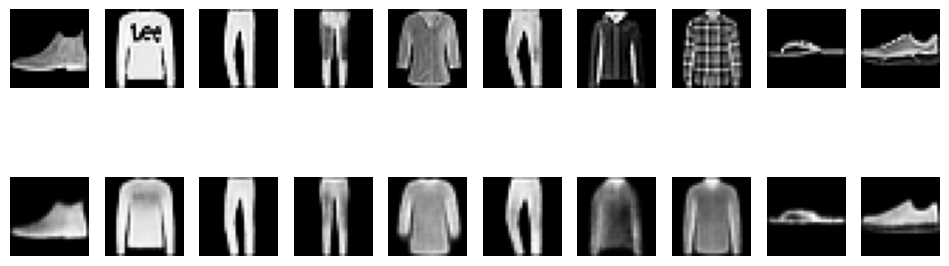

In [72]:
# display outputs
plt.figure(figsize=(12,4))

for i in range(10):

    plt.subplot(2,10,i+1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    plt.subplot(2,10,10+i+1)

    plt.imshow(
        reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

As we can see the outputs are similar to the inputs, but with less detail.

In this part we will use different beta values to see its effect.


Training β = 0.1
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 193ms/step - kl_loss: 4.1222 - loss: 214.5872 - reconstruction_loss: 214.1750
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 194ms/step - kl_loss: 4.1901 - loss: 206.1307 - reconstruction_loss: 205.7117
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 191ms/step - kl_loss: 4.2005 - loss: 210.4769 - reconstruction_loss: 210.0568
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 194ms/step - kl_loss: 4.1615 - loss: 215.6018 - reconstruction_loss: 215.1856
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 194ms/step - kl_loss: 4.2823 - loss: 196.3646 - reconstruction_loss: 195.9364


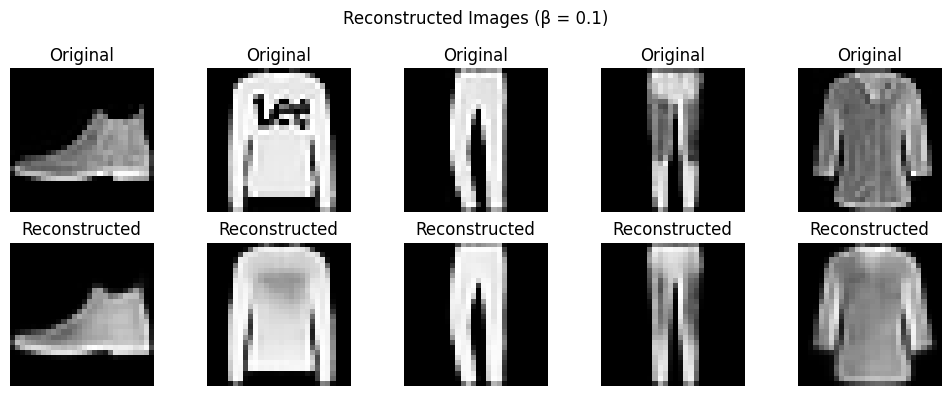


Training β = 5
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 196ms/step - kl_loss: 2.1531 - loss: 216.2913 - reconstruction_loss: 205.5257
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 195ms/step - kl_loss: 2.1445 - loss: 220.8594 - reconstruction_loss: 210.1371
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 195ms/step - kl_loss: 2.0741 - loss: 230.1938 - reconstruction_loss: 219.8234
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 195ms/step - kl_loss: 2.1250 - loss: 208.3785 - reconstruction_loss: 197.7534
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 195ms/step - kl_loss: 2.1103 - loss: 218.2775 - reconstruction_loss: 207.7262


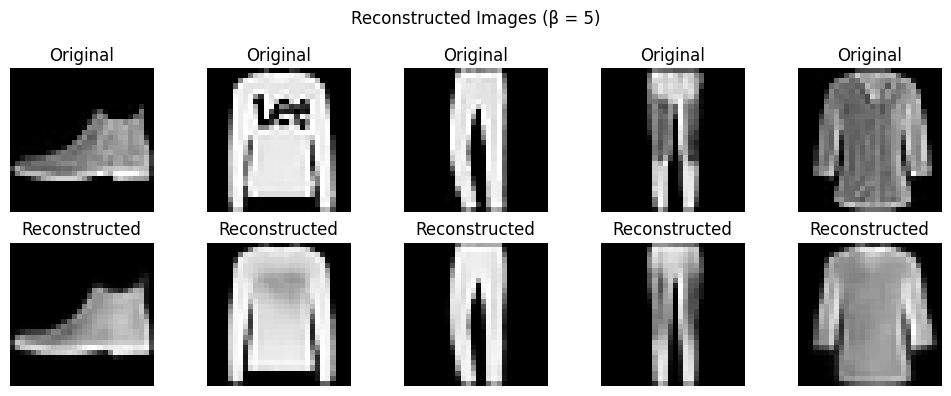


Training β = 10
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 194ms/step - kl_loss: 1.5941 - loss: 221.5004 - reconstruction_loss: 205.5590
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 92s 195ms/step - kl_loss: 1.5649 - loss: 238.8484 - reconstruction_loss: 223.1994
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 92s 195ms/step - kl_loss: 1.5653 - loss: 250.5374 - reconstruction_loss: 234.8848
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - kl_loss: 1.5070 - loss: 221.0094 - reconstruction_loss: 205.9396
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 196ms/step - kl_loss: 1.5224 - loss: 228.4634 - reconstruction_loss: 213.2394


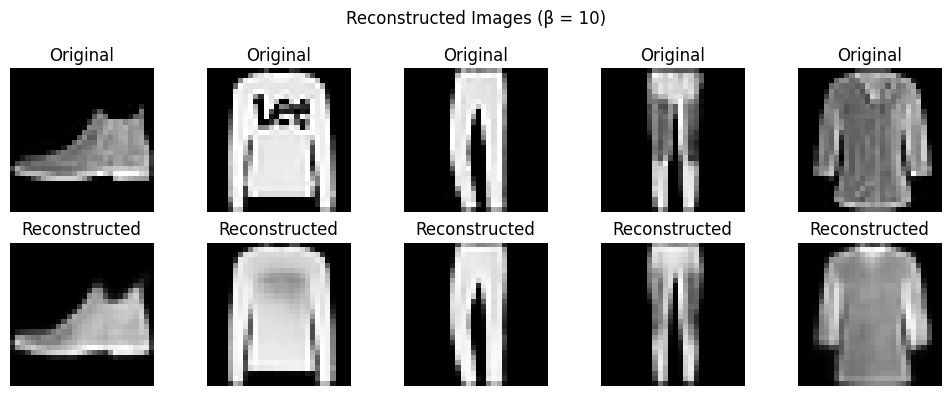

In [78]:
betas = [0.1, 5, 10]

for beta in betas:

    print(f"\nTraining β = {beta}")

    vae = VAE(
        encoder,
        decoder,
        beta=beta
    )

    vae.compile(
        optimizer="adam"
    )

    vae.fit(
        x_train,
        epochs=20,
        batch_size=128,
        verbose=1
    )

    # Reconstruct test images
    z_mean, z_log_var, z = encoder.predict(x_test[:5], verbose=0)

    reconstructed = decoder.predict(z, verbose=0)

    # Display original and reconstructed images
    plt.figure(figsize=(10,4))
    plt.suptitle(f"Reconstructed Images (β = {beta})")

    for i in range(5):

        # Original image
        plt.subplot(2,5,i+1)
        plt.imshow(x_test[i].squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Reconstructed image
        plt.subplot(2,5,i+6)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Analysis of Different β Values

$β = 0.1$

- Reconstruction loss dominates the training objective.
- Reconstructed images are **sharp** and closely resemble the original images.
- The latent space is **less organized**, making it harder to learn independent latent features.

$β = 5$

- Provides a **good balance** between reconstruction quality and latent space regularization.
- Reconstructed images remain clear with good visual quality.
- The latent space becomes **more structured**, allowing for better generalization and smoother interpolation.

$β = 10$

- KL-divergence has a much stronger influence on the loss function.
- Reconstructed images become **blurrier** because the model sacrifices reconstruction accuracy to enforce a more regular latent space.
- The latent variables become **more disentangled**, resulting in a smoother and more interpretable latent space that is better suited for generating new images and performing latent space interpolation.

Conclusion

This experiment demonstrates the central trade-off in a **β-VAE**. As **β** increases, the model places greater emphasis on regularizing the latent space. This leads to improved latent disentanglement and a more structured latent representation, but it also reduces reconstruction quality, producing blurrier images. Lower β values prioritize accurate image reconstruction, whereas higher β values prioritize learning a meaningful and well-organized latent space.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


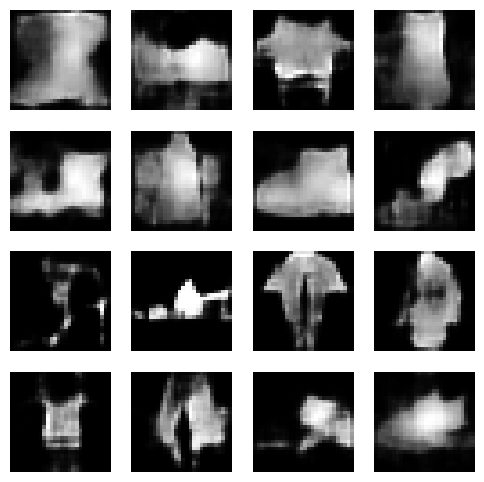

In [75]:
random_latent_vectors = np.random.normal(
    size=(16,latent_dim)
)

generated = decoder.predict(
    random_latent_vectors
)

plt.figure(figsize=(6,6))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

We used our decoder to generate new images. A random latent vector is sampled and passed to the decoder.

In [76]:
z1 = encoder.predict(
    x_test[0:1]
)[2]

z2 = encoder.predict(
    x_test[1:2]
)[2]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


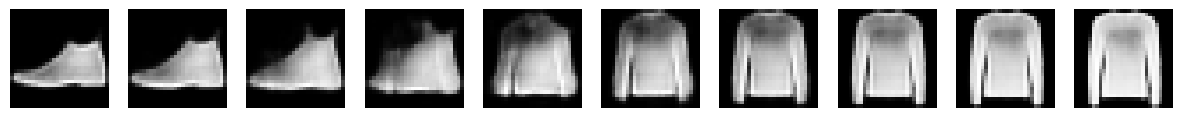

In [77]:
alphas = np.linspace(0,1,10)

plt.figure(figsize=(15,2))

for i,alpha in enumerate(alphas):

    z = (1-alpha)*z1 + alpha*z2

    image = decoder.predict(z)

    plt.subplot(1,10,i+1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()


Two images are first encoded into their corresponding latent vectors:

$z_1$ and $z_2$.

Intermediate latent vectors are computed using linear interpolation:

$$
z = (1-\alpha)z_1 + \alpha z_2
$$

where

$$
0 \leq \alpha \leq 1.
$$

As the value of $\alpha$ gradually changes from 0 to 1, the decoder generates a smooth transition between the two images. This demonstrates that the VAE has learned a continuous and meaningful latent space, where nearby latent vectors correspond to visually similar images.